<a href="https://colab.research.google.com/github/anisaratna/reviewautomation/blob/main/Beauty_Review_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Sentiment Analysis: Azarine Vit C Serum

# Scrapping

In [ ]:
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_multiple_pages(base_url, total_pages=5):
    all_reviews = []
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    for page in range(1, total_pages + 1):
        url = f"{base_url}?page={page}"
        print(f"Mengambil data dari halaman {page}...")

        try:
            response = requests.get(url, headers=headers)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')
                review_elements = soup.find_all('p', class_='text-content')

                for el in review_elements:
                    text = el.get_text(strip=True)
                    if len(text) > 40:
                        all_reviews.append({'review_text': text})

                time.sleep(2)
            else:
                print(f"Halaman {page} tidak bisa diakses.")
                break
        except Exception as e:
            print(f"Error di halaman {page}: {e}")
            break

    return pd.DataFrame(all_reviews)

In [ ]:
# EKSEKUSI
target_product_url = "https://reviews.femaledaily.com/products/treatment/serum-essence/azarine-cosmetic/c-white-lightening-serum"
df_big = scrape_multiple_pages(target_product_url, total_pages=40)

print(f"\nTotal data terkumpul: {len(df_big)} ulasan.")
df_big.to_csv('azarine_reviews_large.csv', index=False)

Mengambil data dari halaman 1...
Mengambil data dari halaman 2...
Mengambil data dari halaman 3...
Mengambil data dari halaman 4...
Mengambil data dari halaman 5...
Mengambil data dari halaman 6...
Mengambil data dari halaman 7...
Mengambil data dari halaman 8...
Mengambil data dari halaman 9...
Mengambil data dari halaman 10...
Mengambil data dari halaman 11...
Mengambil data dari halaman 12...
Mengambil data dari halaman 13...
Mengambil data dari halaman 14...
Mengambil data dari halaman 15...
Mengambil data dari halaman 16...
Mengambil data dari halaman 17...
Mengambil data dari halaman 18...
Mengambil data dari halaman 19...
Mengambil data dari halaman 20...
Mengambil data dari halaman 21...
Mengambil data dari halaman 22...
Mengambil data dari halaman 23...
Mengambil data dari halaman 24...
Mengambil data dari halaman 25...
Mengambil data dari halaman 26...
Mengambil data dari halaman 27...
Mengambil data dari halaman 28...
Mengambil data dari halaman 29...
Mengambil data dari hal

In [ ]:
from google.colab import files

files.download('azarine_reviews_large.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Review Analysis

In [ ]:
!pip install groq
from groq import Groq
import json
from google.colab import drive
import sys

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.0 MB/s eta 0:00:00


In [ ]:
# API Key Groq
client = Groq(api_key="Groq_API_Key")

# Load Data
folder_path = '/content/drive/My Drive/Project Portofolio/Project 3 LLM Competitor Intelligance/'
file_name = 'azarine_reviews_large.csv'

drive.mount('/content/drive', force_remount=True)

sys.path.append(folder_path)

df = pd.read_csv(f'{folder_path}{file_name}')

Mounted at /content/drive


In [ ]:
def analyze_review_with_ai(text):

    system_prompt = "Kamu adalah Senior AI Analyst di perusahaan Kosmetik Global. Tugasmu adalah melakukan ekstraksi informasi dari review pelanggan secara objektif dan terstruktur."

    user_prompt = f"""
    Analisis review produk sunscreen berikut:
    Review: "{text}"

    Berikan output dalam format JSON dengan struktur:
    {{
      "sentiment": "Positif/Negatif/Netral",
      "skin_type_mentioned": "Sebutkan jenis kulit jika ada (misal: berminyak, kering, dll), jika tidak ada tulis 'N/A'",
      "key_benefit": "Apa manfaat utama yang dirasakan pelanggan?",
      "complaint": "Apa keluhan pelanggan? Jika tidak ada tulis 'None'",
      "customer_representative_reply": "Tulis draf balasan resmi dan ramah dari admin brand Azarine untuk review ini."
    }}
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        model="llama-3.3-70b-versatile",
        response_format={"type": "json_object"}
    )
    return chat_completion.choices[0].message.content

In [17]:
import os
import random
from groq import RateLimitError

# Konfigurasi batch processing
batch_size = 50
delay_seconds = 60

# Path untuk menyimpan hasil sementara
output_file = 'ai_beauty_analysis_result.csv'

# Inisialisasi daftar hasil dan cek progress sebelumnya
ai_results = []
start_index = 0

if os.path.exists(output_file):
    print(f"Memuat hasil analisis sebelumnya dari '{output_file}'...")
    df_existing_results = pd.read_csv(output_file)
    ai_results = df_existing_results.to_dict(orient='records')
    start_index = len(ai_results)
    print(f"Melanjutkan dari review ke {start_index + 1}.")
else:
    print("Memulai analisis dari awal.")

print("Sedang dianalisis oleh AI... Mohon tunggu.")

# Loop Analisis dengan batch processing
for i in range(start_index, len(df), batch_size):
    batch_df = df.iloc[i : i + batch_size]
    print(f"Menganalisis batch dari indeks {i} sampai {min(i + batch_size, len(df))}...")

    for idx, row in batch_df.iterrows():
        max_retries = 5
        retry_delay = 1
        num_retries = 0

        while num_retries < max_retries:
            try:
                result = analyze_review_with_ai(row['review_text'])
                ai_results.append(json.loads(result))
                break
            except RateLimitError as e:
                num_retries += 1
                print(f"Rate limit reached for review index {idx}. Retrying in {retry_delay + random.uniform(0, 1):.2f} seconds (Attempt {num_retries}/{max_retries}). Error: {e}")
                time.sleep(retry_delay + random.uniform(0, 1))
                retry_delay = min(60, retry_delay * 2)

                if num_retries == max_retries:
                    print(f"Max retries reached for review index {idx}. Saving progress and stopping.")
                    # Save partial results before exiting
                    df_analysis = pd.DataFrame(ai_results)
                    df_analysis.to_csv(output_file, index=False)
                    sys.exit("Proses dihentikan karena mencapai batas retry RateLimitError.")
            except Exception as e:
                print(f"Error saat menganalisis review indeks {idx}: {e}")
                print("Menyimpan progress dan menghentikan sementara.")
                # Save partial results before exiting
                df_analysis = pd.DataFrame(ai_results)
                df_analysis.to_csv(output_file, index=False)
                sys.exit("Proses dihentikan karena error API lainnya. Silakan coba lagi nanti.") # Menghentikan eksekusi cell

    # Simpan hasil setiap selesai satu batch
    df_analysis = pd.DataFrame(ai_results)
    df_analysis.to_csv(output_file, index=False)
    print(f"Batch selesai. Total {len(ai_results)} ulasan telah dianalisis. Hasil disimpan sementara.")

    # Jeda untuk menghindari rate limit, kecuali jika batch terakhir
    if i + batch_size < len(df):
        print(f"Menunggu {delay_seconds} detik sebelum batch berikutnya...")
        time.sleep(delay_seconds)


# Tampilan Hasil Akhir
df_analysis = pd.DataFrame(ai_results)
print(
"--- HASIL ANALISIS AI SELESAI ---")
display(df_analysis.head())

# Simpan hasil akhir (akan menimpa hasil parsial)
df_analysis.to_csv(output_file, index=False)
print(f"Semua analisis selesai. Hasil akhir disimpan di '{output_file}'.")

Memuat hasil analisis sebelumnya dari 'ai_beauty_analysis_result.csv'...
Melanjutkan dari review ke 6.
Sedang dianalisis oleh AI... Mohon tunggu.
Menganalisis batch dari indeks 5 sampai 55...
Batch selesai. Total 55 ulasan telah dianalisis. Hasil disimpan sementara.
Menunggu 60 detik sebelum batch berikutnya...
Menganalisis batch dari indeks 55 sampai 105...
Batch selesai. Total 105 ulasan telah dianalisis. Hasil disimpan sementara.
Menunggu 60 detik sebelum batch berikutnya...
Menganalisis batch dari indeks 105 sampai 155...
Batch selesai. Total 155 ulasan telah dianalisis. Hasil disimpan sementara.
Menunggu 60 detik sebelum batch berikutnya...
Menganalisis batch dari indeks 155 sampai 205...
Batch selesai. Total 205 ulasan telah dianalisis. Hasil disimpan sementara.
Menunggu 60 detik sebelum batch berikutnya...
Menganalisis batch dari indeks 205 sampai 255...
Batch selesai. Total 255 ulasan telah dianalisis. Hasil disimpan sementara.
Menunggu 60 detik sebelum batch berikutnya...
Meng

,sentiment,skin_type_mentioned,key_benefit,complaint,customer_representative_reply,dark_spot_effect
0,Negatif,dryskin,Harganya terjangkau,Vit C tidak terlalu nampak hasilnya dan bikin ...,Terima kasih atas review Anda tentang produk s...,NaN
1,Positif,NaN,Mencerahkan wajah dan harga terjangkau,NaN,Terima kasih atas review positifnya! Kami sena...,NaN
2,Negatif,sensitif,tidak mengalami iritasi,"wangi parfum terlalu kuat, tidak ada hasil men...",Terima kasih atas ulasan Anda tentang produk s...,NaN
3,Positif,NaN,"Membuat kulit lebih cerah, lembap, dan fresh t...",NaN,Terima kasih atas review positif Anda! Kami sa...,NaN
4,Netral,"Kulit normal hingga kombinasi, kulit sensitif","Mencerahkan dan menyamarkan noda hitam, tekstu...",Dapat menyebabkan kulit kering dan munculnya j...,Terima kasih atas review Anda tentang produk s...,NaN


Semua analisis selesai. Hasil akhir disimpan di 'ai_beauty_analysis_result.csv'.


In [18]:
files.download('ai_beauty_analysis_result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Side-by-Side Experiment

In [ ]:
target_review = "Sorry to say tp wajahku langsung beruntusan setelah 3x pemakaian. Sebenarnya teksturnya cair (khas serumnya Azarine) & ada wangi jeruk lemonnya yg seger banget,jd cepet menyerap di wajah tanpa ada rasa lengket.. Tp yaa gitu, blm seminggu pake udah jerawatan & beruntusan.. Padahal aku ngecek bahan vitamin C-nya kn jg natural ya,tp ternyata wajahku gabisa menerima.. Setelah kuhibahkan ke adekku, ternyata dia juga gak cucok & bikin beruntusan jg.. Akhirnya serum ini malah dipake ibuku & surprisingly keliatan banget efek radiance-nya di wajah ibuku.."

# PROMPT A (BASIC)
def run_prompt_a(text):
    prompt = f"Berikan sentimen dari review ini (Positif/Negatif/Netral): {text}"

    response = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="llama-3.3-70b-versatile"
    )
    return response.choices[0].message.content

print(f"REVIEW ASLI: {target_review}\n")
print("="*30)
print("HASIL PROMPT A (BASIC):")
print(run_prompt_a(target_review))
print("="*30)

REVIEW ASLI: Sorry to say tp wajahku langsung beruntusan setelah 3x pemakaian. Sebenarnya teksturnya cair (khas serumnya Azarine) & ada wangi jeruk lemonnya yg seger banget,jd cepet menyerap di wajah tanpa ada rasa lengket.. Tp yaa gitu, blm seminggu pake udah jerawatan & beruntusan.. Padahal aku ngecek bahan vitamin C-nya kn jg natural ya,tp ternyata wajahku gabisa menerima.. Setelah kuhibahkan ke adekku, ternyata dia juga gak cucok & bikin beruntusan jg.. Akhirnya serum ini malah dipake ibuku & surprisingly keliatan banget efek radiance-nya di wajah ibuku..

HASIL PROMPT A (BASIC):
Sentimen dari review ini adalah Netral. 
Alasan yang menjelaskan hal ini adalah karena reviewer memiliki pengalaman negatif dengan produk tersebut (beruntusan setelah pemakaian), namun mereka juga menyebutkan bahwa produk tersebut memiliki tekstur yang baik dan wanginya yang segar, serta akhirnya menemukan bahwa produk tersebut efektif untuk ibu mereka (menghasilkan efek radiance).


In [ ]:
# PROMPT B (PRO - CoT & Few-Shot)
def run_prompt_b(text):
    system_message = (
        "Kamu adalah AI Quality Auditor. Tugasmu adalah menganalisis ulasan pelanggan "
        "dengan cara mendeteksi slang, memberikan alasan logis, dan kategori masalah."
    )

    user_message = f"""
    Langkah kerja:
    1. Deteksi apakah ada bahasa gaul.
    2. Identifikasi sentimen utama.
    3. Berikan alasan kenapa kamu memilih sentimen tersebut.
    4. Tentukan kategori spesifik.

    Contoh:
    Input: "Suka bgt tapi harganya agak pricey."
    Output: {{ "sentiment": "Netral", "reasoning": "User memuji produk tapi mengeluhkan harga.", "category": "Price" }}

    Review yang harus dianalisis:
    "{text}"

    Berikan output dalam format JSON.
    """

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": system_message},
            {"role": "user", "content": user_message}
        ],
        model="llama-3.3-70b-versatile",
        response_format={"type": "json_object"}
    )
    return response.choices[0].message.content

print("\nHASIL PROMPT B (PRO/STRUCTURED):")
print(run_prompt_b(target_review))


HASIL PROMPT B (PRO/STRUCTURED):
{
  "slang_detection": ["tp", "jd", "yg", "blm", "kn", "jg"],
   "sentiment": "Netral",
   "reasoning": "User mengungkapkan kekecewaan karena produk tidak sesuai dengan kulit mereka, namun juga memberikan pujian tentang tekstur dan efek radiance produk, terutama setelah digunakan oleh ibunya.",
   "category": "Kualitas Produk"
}


# Vizualization

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


<Figure size 6000x6000 with 0 Axes>

<Figure size 6000x6000 with 0 Axes>

In [32]:
# MEMBERSIHKAN DATA

# Salinan data
df_plot = df_analysis.copy()

# Sentimen seragam
df_plot['sentiment'] = df_plot['sentiment'].str.title().str.strip()

def clean_skin_type(text):
    text = str(text).lower()
    if 'berminyak' in text or 'oily' in text: return 'Oily'
    if 'kering' in text or 'dry' in text: return 'Dry'
    if 'kombinasi' in text or 'combination' in text: return 'Combination'
    if 'sensitif' in text or 'sensitive' in text: return 'Sensitive'
    if 'normal' in text: return 'Normal'
    if 'jerawat' in text or 'acne' in text: return 'Acne Prone'
    return 'Other/Not Specified'

df_plot['skin_type_clean'] = df_plot['skin_type_mentioned'].apply(clean_skin_type)

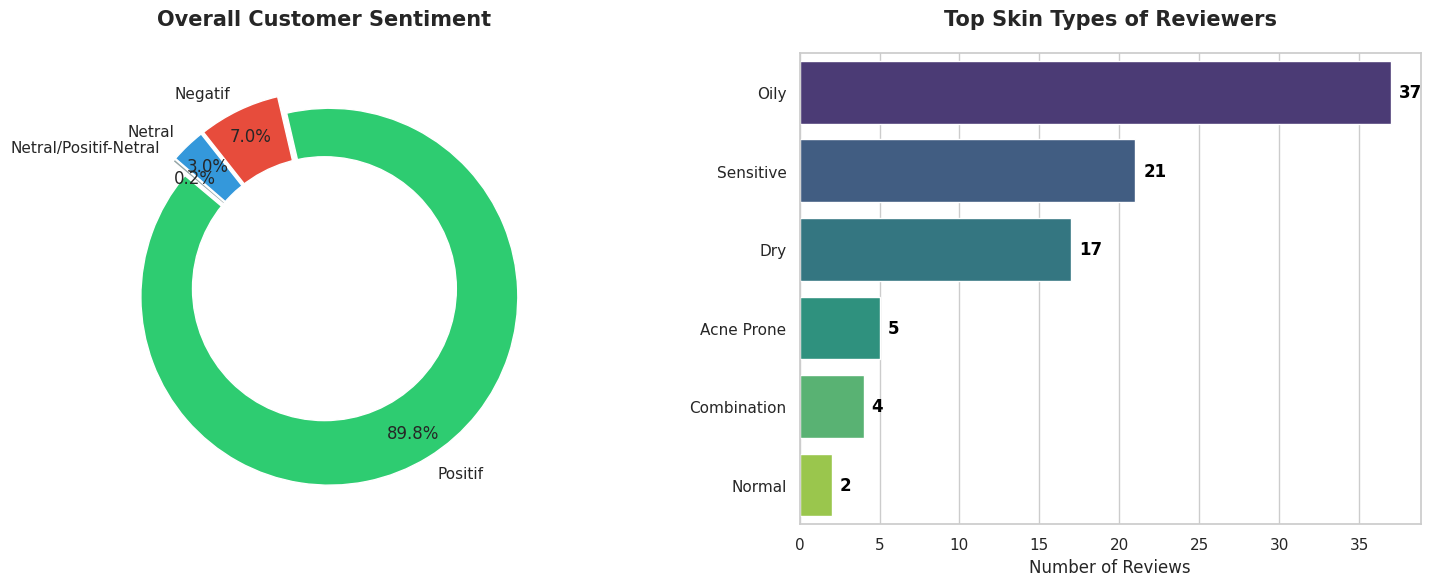

In [37]:
# SETUP VISUALISASI

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: PIE CHART SENTIMEN ---
sentiment_data = df_plot['sentiment'].value_counts()
colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}

current_colors = [colors.get(label, '#95a5a6') for label in sentiment_data.index]

ax[0].pie(
    sentiment_data,
    labels=sentiment_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=current_colors,
    explode=[0.05] * len(sentiment_data),
    pctdistance=0.85
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax[0].add_artist(centre_circle)
ax[0].set_title('Overall Customer Sentiment', fontsize=15, fontweight='bold', pad=20)

# --- PLOT 2: BAR CHART JENIS KULIT ---
skin_data = df_plot[df_plot['skin_type_clean'] != 'Other/Not Specified']['skin_type_clean'].value_counts()

sns.barplot(
    x=skin_data.values,
    y=skin_data.index,
    ax=ax[1],
    palette='viridis',
    hue=skin_data.index,
    legend=False
)
ax[1].set_title('Top Skin Types of Reviewers', fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel('Number of Reviews', fontsize=12)
ax[1].set_ylabel('')

# Menambahkan angka di ujung bar
for i, v in enumerate(skin_data.values):
    ax[1].text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout(pad=4.0) # Memberikan ruang antar grafik agar tidak tumpang tindih
plt.show()


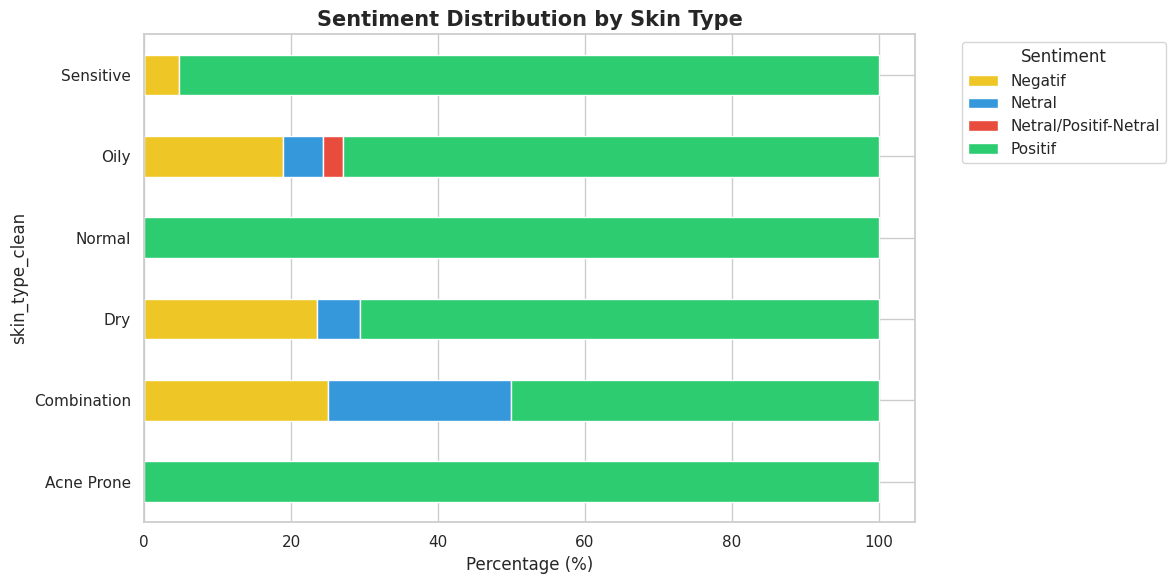

In [41]:
# Filter data
df_filtered = df_plot[df_plot['skin_type_clean'] != 'Other/Not Specified']

# tabel silang (Cross-tabulation)
ct = pd.crosstab(df_filtered['skin_type_clean'], df_filtered['sentiment'], normalize='index') * 100

# Visualisasi
ct.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#eec626', '#3498db', '#e74c3c', '#2ecc71'])
plt.title('Sentiment Distribution by Skin Type', fontsize=15, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [42]:
# Hitung 10 Manfaat Teratas
top_benefits = df_analysis['key_benefit'].str.lower().value_counts().head(10)

# Hitung 10 Keluhan Teratas
top_complaints = df_analysis[df_analysis['complaint'].str.lower() != 'none']['complaint'].str.lower().value_counts().head(10)

print("Top 5 Benefits Found by AI:")
print(top_benefits.head(5))

Top 5 Benefits Found by AI:
key_benefit
mencerahkan                  6
mencerahkan kulit            5
mencerahkan wajah            5
membuat kulit lebih cerah    4
bikin cerah                  3
Name: count, dtype: int64


# Summary

In [43]:
# MENGAMBIL DATA UNIK TERBANYAK

# Keluhan yang bukan 'None'
all_complaints = df_analysis[df_analysis['complaint'].str.lower() != 'none']['complaint'].value_counts().head(20).index.tolist()

# Manfaat utama
all_benefits = df_analysis['key_benefit'].value_counts().head(20).index.tolist()

# Konversi ke string untuk dimasukkan ke prompt
complaints_str = "\n- ".join(all_complaints)
benefits_str = "\n- ".join(all_benefits)

# EXECUTIVE SUMMARY GENERATOR

def generate_ceo_report(benefits, complaints):
    system_prompt = (
        "Kamu adalah Senior Strategy Consultant untuk perusahaan kosmetik global. "
        "Tugasmu adalah memberikan Executive Briefing berdasarkan ribuan data ulasan pelanggan. "
        "Berikan rekomendasi yang tajam, teknis, dan berorientasi pada profit."
    )

    user_prompt = f"""
    Berdasarkan analisis ulasan pelanggan pada produk Azarine, berikut adalah ringkasan datanya:

    MANFAAT UTAMA YANG DIRASAKAN PELANGGAN:
    - {benefits}

    KELUHAN UTAMA PELANGGAN:
    - {complaints}

    TEMUAN KHUSUS:
    "Pemilik tipe kulit KOMBINASI menunjukkan variasi sentimen yang paling tinggi (campuran positif dan negatif)."

    Tugasmu: Buatlah laporan singkat untuk jajaran Direktur (C-Level) dalam Bahasa Indonesia yang mencakup:
    1. **Product Strength:** Mengapa produk ini laku?
    2. **Critical Weakness:** Apa risiko terbesar yang bisa membuat pelanggan pindah ke kompetitor?
    3. **The "Combination Skin" Mystery:** Berikan hipotesis mengapa kulit kombinasi menunjukkan hasil yang paling bervariasi.
    4. **Actionable R&D Roadmap:** Berikan 2 langkah konkret untuk pengembangan formula produk selanjutnya.
    """

    try:
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {e}"

# --- 3. EKSEKUSI DAN TAMPILKAN LAPORAN ---
report = generate_ceo_report(benefits_str, complaints_str)
print("\n" + "="*50)
print("💼 EXECUTIVE STRATEGY REPORT (AI GENERATED)")
print("="*50 + "\n")
print(report)


💼 EXECUTIVE STRATEGY REPORT (AI GENERATED)

**Laporan Singkat: Analisis Ulasan Pelanggan Azarine Sunscreen**

**1. Product Strength:**
Produk Azarine Sunscreen memiliki kekuatan utama dalam mencerahkan dan melembabkan kulit, serta memiliki tekstur yang ringan dan cepat meresap. Kandungan Niacinamide, Hyaluronic Acid, dan Kakadu Plum juga efektif dalam mencerahkan kulit dan menjaga kelembapan. Ini membuat produk ini laku di pasaran dan disukai oleh banyak pelanggan.

**2. Critical Weakness:**
Risiko terbesar yang bisa membuat pelanggan pindah ke kompetitor adalah ketidakcocokan produk dengan tipe kulit tertentu, terutama kulit kombinasi. Beberapa pelanggan melaporkan bahwa produk ini dapat menyebabkan kulit kering, berminyak, atau lengket, terutama jika digunakan terlalu sering. Selain itu, beberapa pelanggan juga tidak merasakan efek mencerahkan yang signifikan, terutama jika digunakan dalam jangka waktu yang lama.

**3. The "Combination Skin" Mystery:**
Hipotesis kami adalah bahwa ku